In [96]:
# load data from hugging face
from datasets import load_dataset
ds = load_dataset("Ez4Real/515K_Hotel_Reviews")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['review_date', 'hotel_name', 'review'],
        num_rows: 515738
    })
})


In [125]:
# convert data to pandas dataframe
import pandas as pd
df = pd.DataFrame(ds["train"])
df.head()

,review_date,hotel_name,review
0,8/3/2017,Hotel Arena,I am so angry that i made this post available...
1,8/3/2017,Hotel Arena,No Negative No real complaints the hotel was g...
2,7/31/2017,Hotel Arena,Rooms are nice but for elderly a bit difficul...
3,7/31/2017,Hotel Arena,My room was dirty and I was afraid to walk ba...
4,7/24/2017,Hotel Arena,You When I booked with your company on line y...


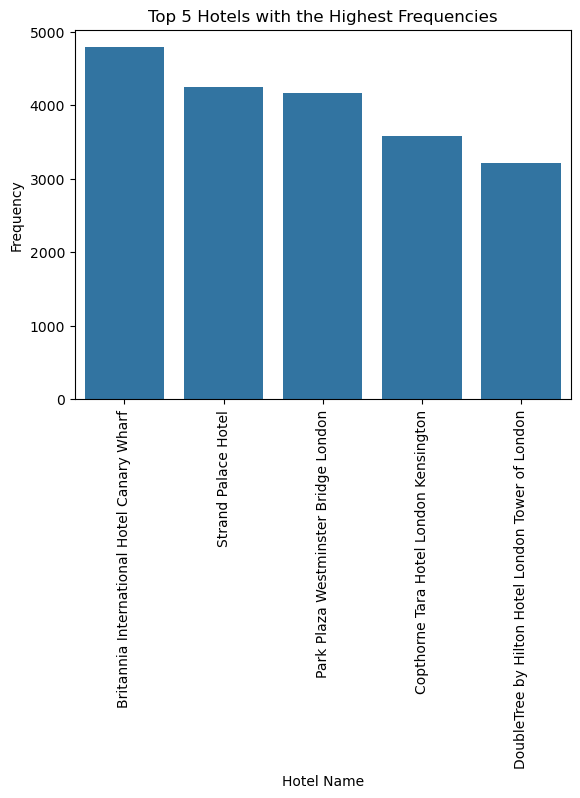

In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# bar chart of the top 5 hotels with the most number of reviews
hotel_counts = df['hotel_name'].value_counts().head(5)
sns.barplot(x = hotel_counts.index, y = hotel_counts.values)

plt.xlabel('Hotel Name')
plt.ylabel('Frequency')
plt.title('Top 5 Hotels with the Highest Frequencies')

plt.xticks(rotation=90)
plt.show()

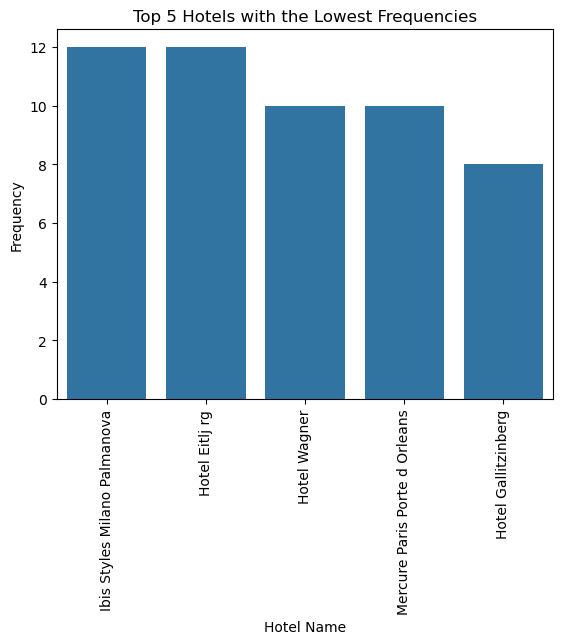

In [129]:
# bar chart of the top 5 hotels with the least number of reviews
hotel_counts = df['hotel_name'].value_counts().tail(5)
sns.barplot(x = hotel_counts.index, y = hotel_counts.values)

plt.xlabel('Hotel Name')
plt.ylabel('Frequency')
plt.title('Top 5 Hotels with the Lowest Frequencies')

plt.xticks(rotation=90)
plt.show()

In [131]:
f"There are {len(np.unique(df['hotel_name']))} unique hotels in the dataset."

'There are 1492 unique hotels in the dataset.'

In [133]:
# check for missing values
df.isna().sum()

review_date    0
hotel_name     0
review         0
dtype: int64

In [135]:
# average review length of the full dataset
f"On average, a review contains {df['review'].str.len().mean()} characters for the full dataset."

'On average, a review contains 188.41923612376826 characters for the full dataset.'

In [137]:
# select top 8 hotels with the lowest number of reviews
df_subset = df[df['hotel_name'].isin(df['hotel_name'].value_counts().tail(8).index)].copy()
df_subset.head()

,review_date,hotel_name,review
43688,5/31/2017,Mercure Paris Porte d Orleans,A bit on the expensive side not necessarily o...
43689,6/5/2016,Mercure Paris Porte d Orleans,Check in and check out were very poor and too...
43690,1/5/2016,Mercure Paris Porte d Orleans,Some minor problems at the reception but were...
43691,12/9/2015,Mercure Paris Porte d Orleans,Like any other business hotel the place is a ...
43692,6/7/2017,Mercure Paris Porte d Orleans,Room service trays left outside of rooms in t...


In [139]:
# extract year from review_date and create new column
df_subset['year'] = df_subset['review_date'].str[-4:]
df_subset.head()

,review_date,hotel_name,review,year
43688,5/31/2017,Mercure Paris Porte d Orleans,A bit on the expensive side not necessarily o...,2017
43689,6/5/2016,Mercure Paris Porte d Orleans,Check in and check out were very poor and too...,2016
43690,1/5/2016,Mercure Paris Porte d Orleans,Some minor problems at the reception but were...,2016
43691,12/9/2015,Mercure Paris Porte d Orleans,Like any other business hotel the place is a ...,2015
43692,6/7/2017,Mercure Paris Porte d Orleans,Room service trays left outside of rooms in t...,2017


In [141]:
f"The subset contains {len(df_subset)} entries."

'The subset contains 88 entries.'

In [143]:
# average review length of the subset
f"On average, a review contains {df_subset['review'].str.len().mean()} characters for the subset."

'On average, a review contains 196.5681818181818 characters for the subset.'

In [145]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import time

# https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def detailed_timing(review):
    start_total = time.time()

    # tokenization: convert text to numerical tokens
    start_tokenization = time.time()
    inputs = tokenizer(review, return_tensors="pt", truncation=True, padding=True).to(device)
    tokenization_time = time.time() - start_tokenization

    # model inference: prediction through neural network
    start_inference = time.time()
    with torch.no_grad():
        logits = model(**inputs).logits
    inference_time = time.time() - start_inference

    # class prediction: extracting classification label
    predicted_class_id = logits.argmax().item()
    total_time = time.time() - start_total
    
    return len(review), model.config.id2label[predicted_class_id], tokenization_time, inference_time, total_time

df_subset[['length', 'label', 'tokenization', 'inference', 'total time']] = df_subset['review'].apply(detailed_timing).apply(pd.Series)
df_subset

,review_date,hotel_name,review,year,length,label,tokenization,inference,total time
43688,5/31/2017,Mercure Paris Porte d Orleans,A bit on the expensive side not necessarily o...,2017,709,NEGATIVE,0.000000,0.379944,0.379944
43689,6/5/2016,Mercure Paris Porte d Orleans,Check in and check out were very poor and too...,2016,303,NEGATIVE,0.005138,0.134922,0.140060
43690,1/5/2016,Mercure Paris Porte d Orleans,Some minor problems at the reception but were...,2016,154,POSITIVE,0.003023,0.060438,0.063461
43691,12/9/2015,Mercure Paris Porte d Orleans,Like any other business hotel the place is a ...,2015,178,POSITIVE,0.000000,0.063822,0.063822
43692,6/7/2017,Mercure Paris Porte d Orleans,Room service trays left outside of rooms in t...,2017,92,NEGATIVE,0.000000,0.050135,0.050135
...,...,...,...,...,...,...,...,...,...
485016,6/20/2017,Ibis Styles Milano Palmanova,Would have liked tea coffee facilities in roo...,2017,95,POSITIVE,0.001228,0.026658,0.027886
485017,6/13/2017,Ibis Styles Milano Palmanova,The room was very very dirty We had ants in t...,2017,152,NEGATIVE,0.001031,0.046428,0.047459
485018,4/30/2017,Ibis Styles Milano Palmanova,Cold rooms poor cable TV could be better brea...,2017,93,NEGATIVE,0.001026,0.032030,0.033056
485019,4/25/2017,Ibis Styles Milano Palmanova,Nothing to see in the neighbourhood Nice size...,2017,93,POSITIVE,0.001048,0.028736,0.029783


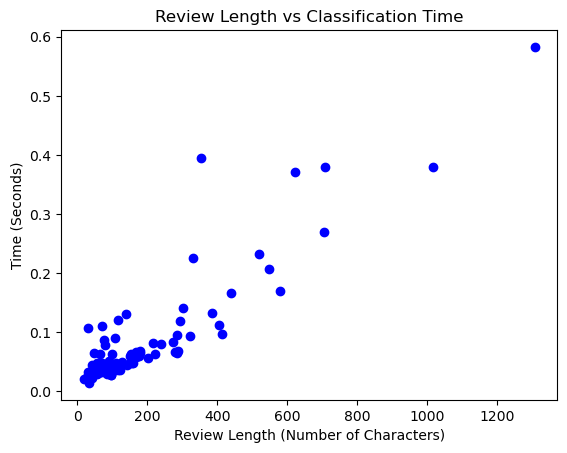

In [147]:
import matplotlib.pyplot as plt

# scatterplot of relationship between length of review and classification time
plt.scatter(df_subset['length'], df_subset['total time'], color='blue', marker='o')

plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Time (Seconds)")
plt.title("Review Length vs Classification Time")

plt.show()

In [149]:
# compute percentage of positive reviews for each hotel
hotel_percentage = df_subset.groupby('hotel_name').agg(
    positive_percentage=('label', lambda x: (x == 'POSITIVE').mean() * 100),
    review_count=('label', 'size')
).reset_index()

hotel_percentage['positive_percentage'] = hotel_percentage['positive_percentage'].round(2)

hotel_percentage

,hotel_name,positive_percentage,review_count
0,Boundary Rooms Suites,75.00,12
1,Hotel Daniel Paris,66.67,12
2,Hotel Eitlj rg,50.00,12
3,Hotel Gallitzinberg,37.50,8
4,Hotel Wagner,60.00,10
5,Ibis Styles Milano Palmanova,33.33,12
6,Le Lavoisier,75.00,12
7,Mercure Paris Porte d Orleans,40.00,10


In [151]:
# compute number of reviews by hotel and year
grouped = df_subset.groupby(['hotel_name', 'year'])
review_counts = grouped.size().reset_index(name='review_count')
review_counts.pivot(index='hotel_name', columns='year', values='review_count').fillna(0).astype(int)

year,2015,2016,2017
hotel_name,,,
Boundary Rooms Suites,6,5,1
Hotel Daniel Paris,4,5,3
Hotel Eitlj rg,1,5,6
Hotel Gallitzinberg,3,2,3
Hotel Wagner,0,3,7
Ibis Styles Milano Palmanova,0,0,12
Le Lavoisier,1,10,1
Mercure Paris Porte d Orleans,4,4,2


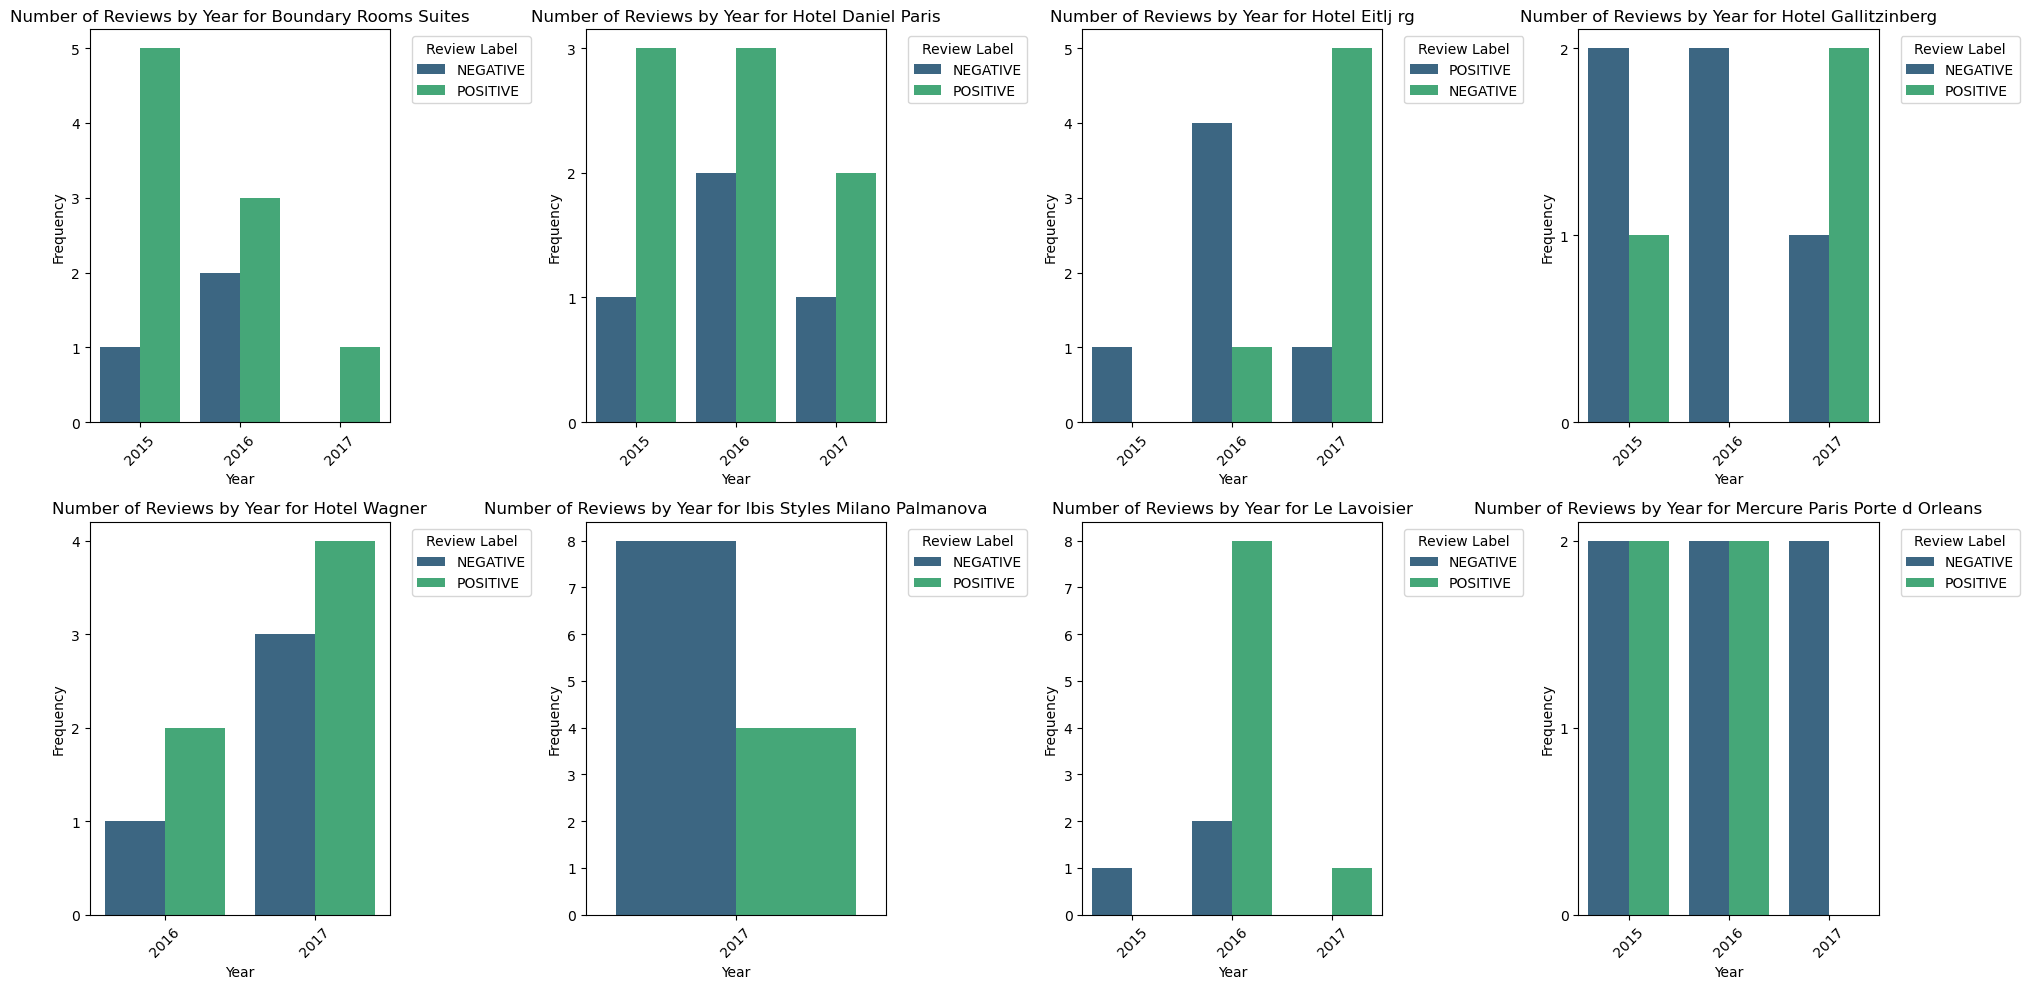

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

hotels = np.unique(df_subset['hotel_name'])

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, hotel in enumerate(hotels):
    df_hotel = df_subset[df_subset['hotel_name'] == hotel]
    df_grouped = df_hotel.groupby(['year', 'label']).size().reset_index(name='frequency')
    
    sns.barplot(
        data=df_grouped,
        x='year', 
        y='frequency', 
        hue='label',  # separate bars for POSITIVE and NEGATIVE
        palette='viridis',
        ax=axes[idx]
    )
    
    axes[idx].set_xlabel('Year')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Number of Reviews by Year for {hotel}')
    axes[idx].tick_params(axis='x', rotation=45)

    max_y = df_grouped['frequency'].max()
    axes[idx].set_yticks(range(0, max_y + 1, 1))  # ensure y-axis are ints
    
    axes[idx].legend(title='Review Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()